In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  
import seaborn as sns
import os
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

%matplotlib inline  

plt.style.use("ggplot")

In [2]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score


import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf


In [3]:
#Load Dataset
import zipfile
z = zipfile.ZipFile(r"C:\Users\sangi\Downloads\archive (22).zip")
z.extractall()

# EDA



In [5]:
totaldata_glioma = os.listdir(r"C:\Users\sangi\OneDrive\Desktop\deep learning\Training\glioma")
number_files_glioma = len(totaldata_glioma)
print("Total glioma type image: " + str(number_files_glioma))

totaldata_meningioma = os.listdir(r"C:\Users\sangi\OneDrive\Desktop\deep learning\Training\meningioma")
number_files_meningioma = len(totaldata_meningioma)
print("Total meningioma type image :" + str(number_files_meningioma))

totalno_tumor = os.listdir(r"C:\Users\sangi\OneDrive\Desktop\deep learning\Training\notumor")
no_tumor = len(totalno_tumor)
print("No Tumor image " + str(no_tumor ))


totaldata_pituitary = os.listdir(r"C:\Users\sangi\OneDrive\Desktop\deep learning\Training\pituitary")
number_files_pituitary = len(totaldata_pituitary)
print("No pituitary image " + str(number_files_pituitary))




#sum of image
total_image=(number_files_glioma+number_files_meningioma+no_tumor+number_files_pituitary)
print("Total Image:"+str(total_image))

Total glioma type image: 1321
Total meningioma type image :1339
No Tumor image 1595
No pituitary image 1457
Total Image:5712


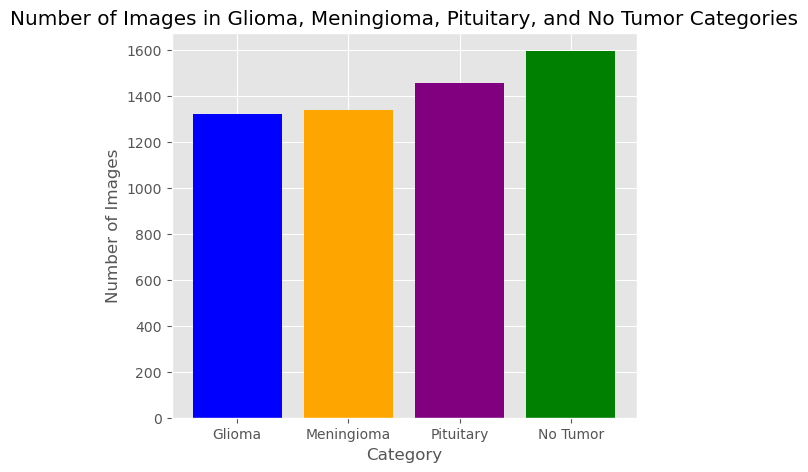

In [6]:
plt.figure(figsize=(6, 5))

totaldata_glioma = 1321 
totaldata_meningioma = 1339  
totalno_tumor = 1595
totaldata_pituitary = 1457

data = {
    "Glioma": totaldata_glioma, 
    "Meningioma": totaldata_meningioma,
    "Pituitary": totaldata_pituitary,
    "No Tumor": totalno_tumor
}

# Plot
plt.bar(data.keys(), data.values(), color=['blue', 'orange', 'purple', 'green'])
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Number of Images in Glioma, Meningioma, Pituitary, and No Tumor Categories')
plt.show()


In [7]:
import os
import cv2

x_train = []
y_train = []
image_size = 150
labels = ["glioma", "meningioma", "notumor", "pituitary"]

for i in labels:
    folderpath = os.path.join(r"C:\Users\sangi\OneDrive\Desktop\deep learning\Training", i)
    
    for j in os.listdir(folderpath):
        img = cv2.imread(os.path.join(folderpath, j))
        img = cv2.resize(img, (image_size, image_size))
        x_train.append(img)
        y_train.append(i)
        
        

for i in labels:
    folderpath = os.path.join(r"C:\Users\sangi\OneDrive\Desktop\deep learning\Testing", i)
    
    for j in os.listdir(folderpath):
        img = cv2.imread(os.path.join(folderpath, j))
        img = cv2.resize(img, (image_size, image_size))
        x_train.append(img)
        y_train.append(i)

        
x_train=np.array(x_train)
y_train=np.array(y_train)


In [8]:
x_train,y_train=shuffle(x_train,y_train,random_state=100)
x_train.shape

(7023, 150, 150, 3)

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x_train,y_train,test_size=0.2,random_state=100)

In [ ]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))  
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)  

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))  
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)  


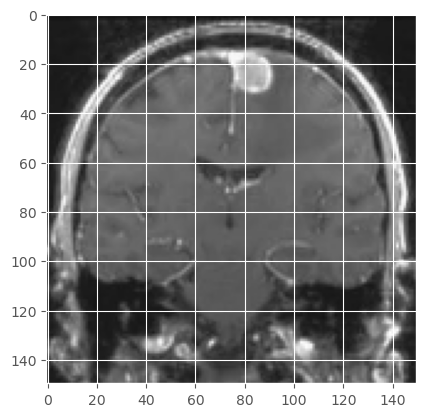

In [11]:
plt.imshow(x_train[1000])

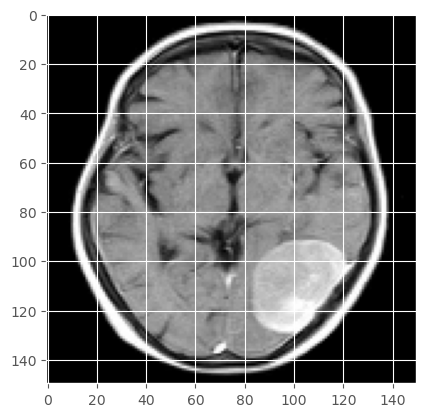

In [12]:
plt.imshow(x_train[5000])

In [13]:
print(y_test[0])  


[0. 0. 1. 0.]


In [14]:
print(y_train[0])  

[0. 0. 1. 0.]


# CNN

In [16]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape=(150,150,3)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))

C:\Users\sangi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 146, 146, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 69, 69, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 69, 69, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 30, 30, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 10, 10, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,447,044 (16.96 MB)

 Trainable params: 4,447,044 (16.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam',                 
    metrics=['accuracy']              
)


In [19]:
history = model.fit(
    x_train,            
    y_train,           
    epochs=50,         
    validation_split=0.1,  
    batch_size=32       
)

Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.3203 - loss: 2.8663 - val_accuracy: 0.6673 - val_loss: 0.8702
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.6717 - loss: 0.7698 - val_accuracy: 0.6299 - val_loss: 0.9548
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.7664 - loss: 0.5733 - val_accuracy: 0.6566 - val_loss: 0.8618
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.8046 - loss: 0.4774 - val_accuracy: 0.7527 - val_loss: 0.6467
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8203 - loss: 0.4108 - val_accuracy: 0.7740 - val_loss: 0.6659
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.8598 - loss: 0.3543 - val_accuracy: 0.7384 - val_loss: 0.6591
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.8651 - loss: 0.3275 - val_accuracy: 0.8488 - val_loss: 0.4317
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.8962 - loss: 0.2638 - val_accu

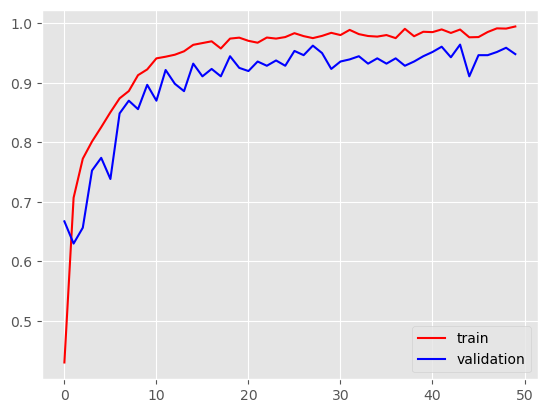

In [42]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

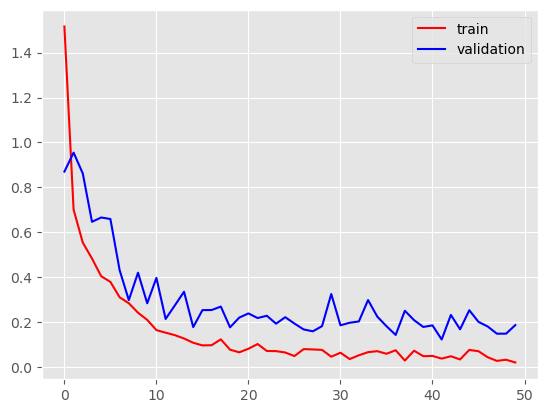

In [44]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

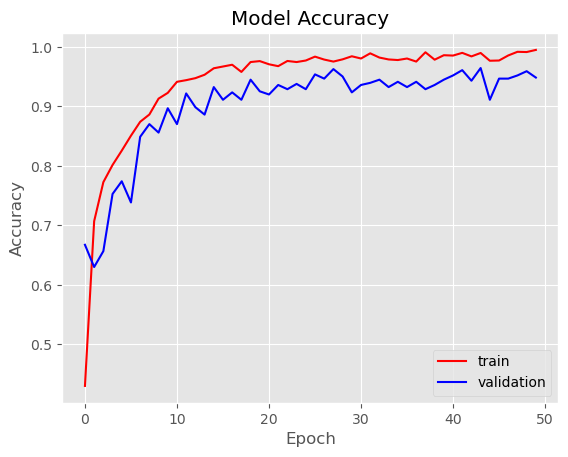

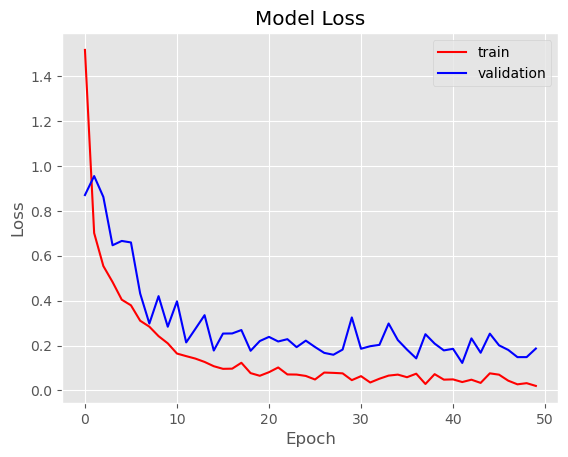

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 460ms/step


ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Get predictions on test set
y_pred = np.argmax(model.predict(x_test), axis=-1)  # Use x_test for predictions
y_true = y_test  # Directly use y_test if available as an array

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


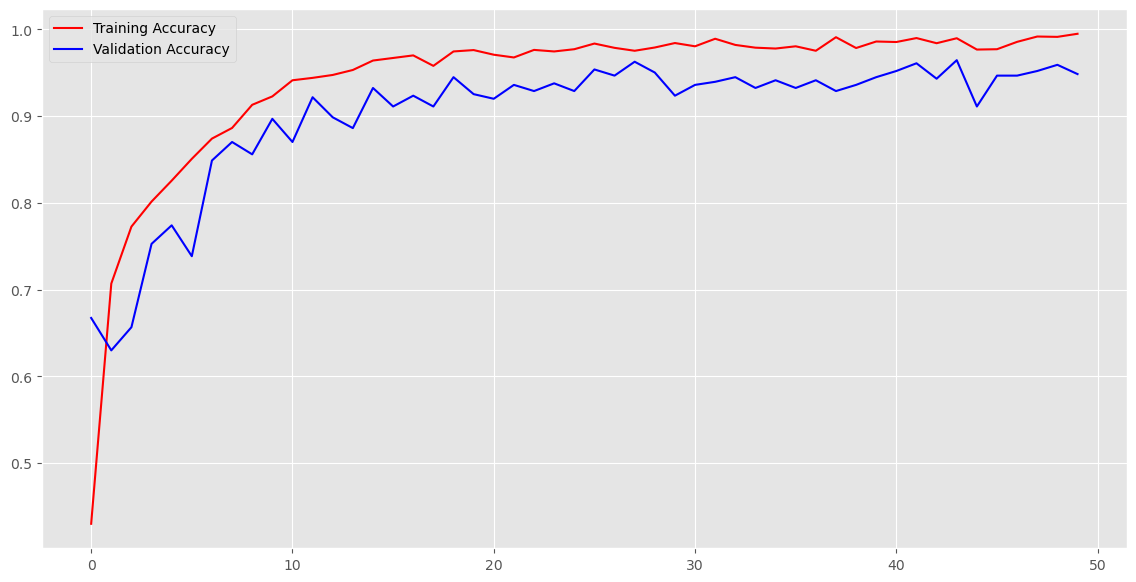

In [64]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

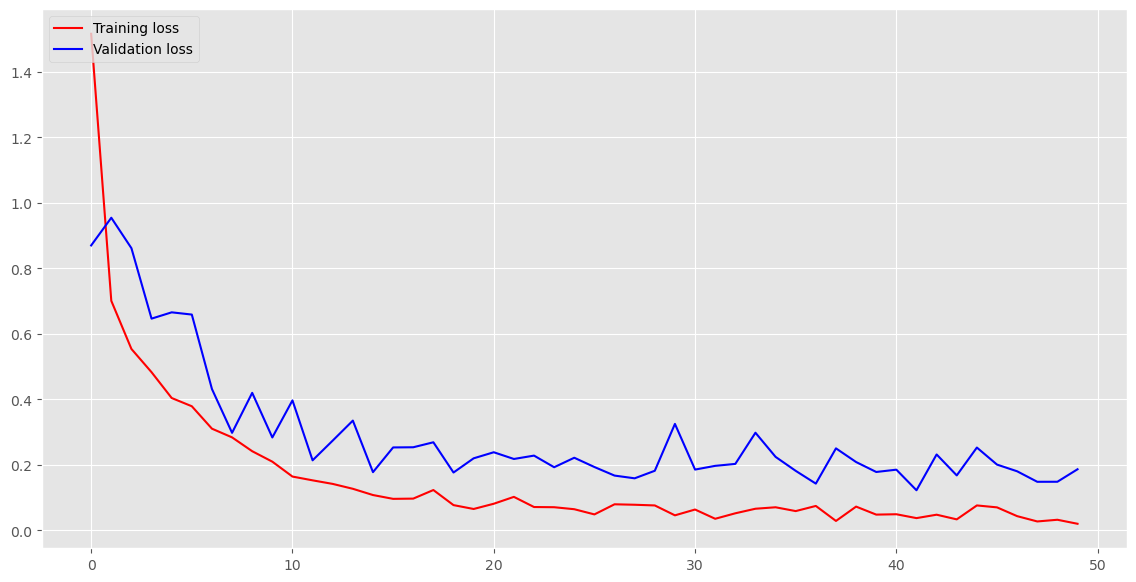

In [66]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()

In [80]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

44/44 - 20s - 445ms/step - accuracy: 0.9480 - loss: 0.2674
Test Loss: 0.2673790454864502
Test Accuracy: 0.9480426907539368


In [82]:
prediction=model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 443ms/step


In [84]:
Y_pred=prediction.argmax(axis=1)

In [88]:
Y_true = y_test.argmax(axis=1)

In [90]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


cm = confusion_matrix(Y_true, Y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred, target_names=['Glioma', 'Meningioma',"Pituitary","No_Tumor"]))

Confusion Matrix:
[[308   6   0   7]
 [ 20 284  16   9]
 [  2   3 398   4]
 [  1   2   3 342]]

Classification Report:
              precision    recall  f1-score   support

      Glioma       0.93      0.96      0.94       321
  Meningioma       0.96      0.86      0.91       329
   Pituitary       0.95      0.98      0.97       407
    No_Tumor       0.94      0.98      0.96       348

    accuracy                           0.95      1405
   macro avg       0.95      0.95      0.95      1405
weighted avg       0.95      0.95      0.95      1405



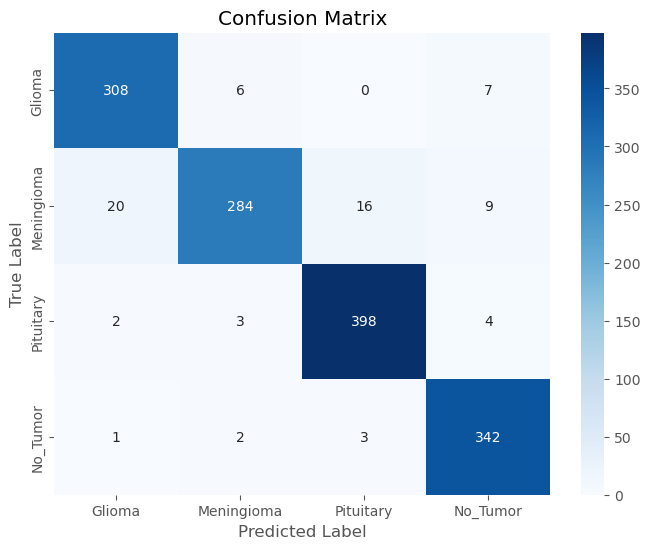

In [92]:
from sklearn.metrics import confusion_matrix

label_names = ['Glioma', 'Meningioma',"Pituitary","No_Tumor"]

# Generate confusion matrix
cm = confusion_matrix(Y_true, Y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [96]:
model.save('Brain_timor.h5')

In [98]:
from tensorflow.keras.models import load_model

model = load_model('Brain_timor.h5')